In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
def f(x):
      return (3*x**2) - (4*x) + 5

In [3]:
f(3)

20

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
ys 

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

In [5]:
#plt.plot(xs, ys)

In [6]:
h = 0.0000001
x = 2/3
(f(x + h) - f(x))/h

2.9753977059954195e-07

In [7]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h 
d2 = a*b + c

print(f"d1 is {d1}. d2 is {d2}. slope is {(d2 - d1)/h}")

d1 is 4.0. d2 is 3.999699999999999. slope is -3.000000000010772


### Neural Networks
* Honestly can't wait 


In [8]:
class Value:
    def __init__(self, data, _children=(), _op="", label = ""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children) #for efficiency
        self._op = _op 
        self.label = label
    def __repr__(self):
        return f"Value(data = {self.data})"
            
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+" )
    
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __neg__(self): 
        return self * -1
    
    def __sub__(self, other): 
        return self + (-other)
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out  
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out  
     

    def __rmul__(self, other): #other * self
        return self * other
    
    def __radd__(self, other):
        return self + other 
    

    def __truediv__(self, other):
        return ((self) * (other**(-1)))

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out 
    
        
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward= _backward 
        return out

    
    def backward(self):

        topological_graph = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topological_graph.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topological_graph):
            node._backward()

        
 

a = Value(2.0, label = "a")
b = Value(-3.0, label = "b")
c = Value(10.0, label = "c")
d = a * b + c
e = a*b; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0, label = "f")
l = d * f; l.label = "l"



"""
e = d ** 2 
f = e ** 2(a+b) 
g = 100/f
print(f"{g.data:.4f}")
"""
l

Value(data = -8.0)

In [9]:
a = 2.0
b = 3.00
b /a

1.5

In [10]:
from graphviz import Digraph  

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot =  Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges =  trace(root)
    for n in nodes:
        uid = str(id(n)) 
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an op node 
           dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
           dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot
         


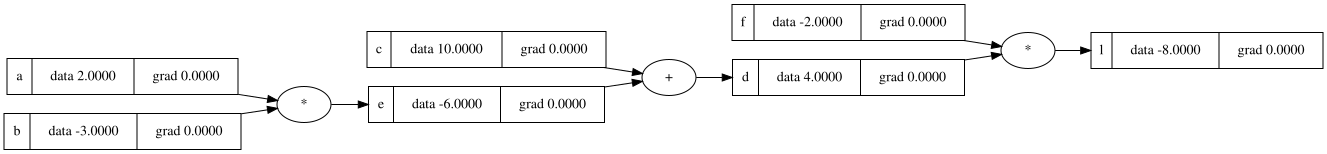

In [11]:
draw_dot(l)

In [12]:
l.grad = 1.0
l._backward()
d._backward()
e._backward()



In [13]:
"""l.grad = 1.0
# dl/dd = f
d.grad = -2.00
# dl/df = d 
f.grad = 4.0
# dl/dc = dl/dd * dd/dc  ---> f * 1
c.grad = -2.00
e.grad = -2.00
# dl/da = dl/de * de/da ---> -2.00 * -3.00
a.grad = 6.00
# dl/db = dl/de * de/db  ---> -2.00 * 2.00
b.grad = -4.00
"""


'l.grad = 1.0\n# dl/dd = f\nd.grad = -2.00\n# dl/df = d \nf.grad = 4.0\n# dl/dc = dl/dd * dd/dc  ---> f * 1\nc.grad = -2.00\ne.grad = -2.00\n# dl/da = dl/de * de/da ---> -2.00 * -3.00\na.grad = 6.00\n# dl/db = dl/de * de/db  ---> -2.00 * 2.00\nb.grad = -4.00\n'

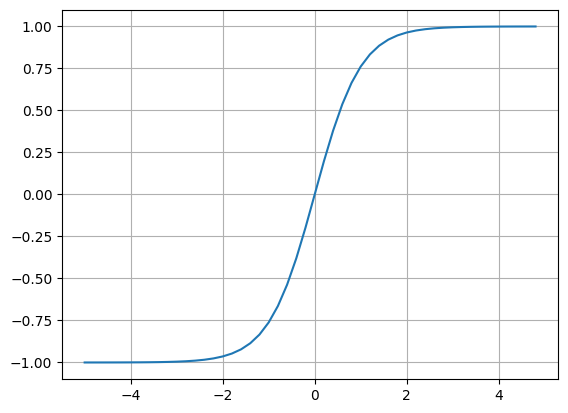

In [14]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid(); 

In [15]:
def lol():

    h = 0.001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    l = d * f; l.label = 'l'
    l1 = l.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    l = d * f; l.label = 'l'
    l2 = l.data

  
lol()

        

In [16]:
# inputs x1, x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

# Weights ---> w1, w2 
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

# Bias of the Neuron 
b = Value (6.8813735870195432, label = 'b')

# Activation function of the neuron --> x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()


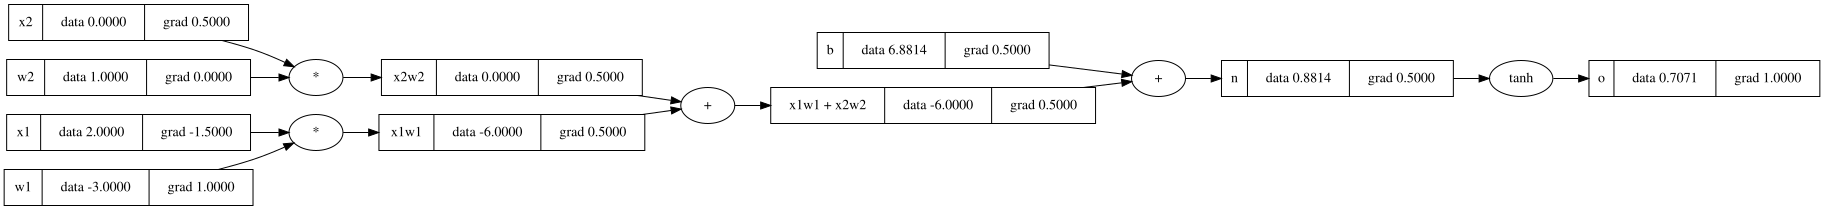

In [17]:
draw_dot(o)

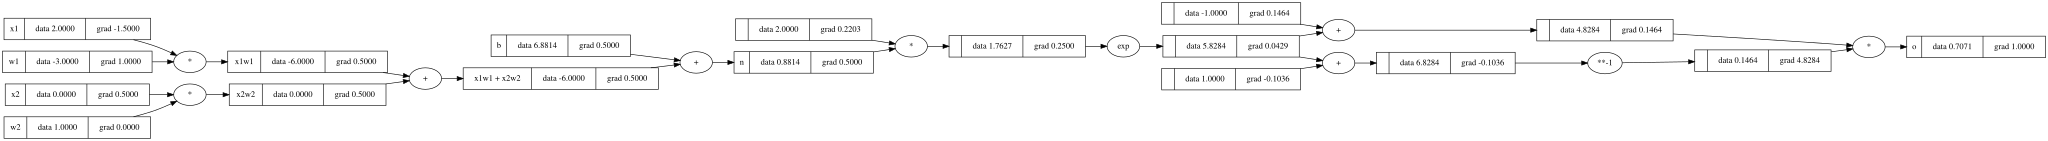

In [18]:
# inputs x1, x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

# Weights ---> w1, w2 
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

# Bias of the Neuron 
b = Value (6.8813735870195432, label = 'b')

# Activation function of the neuron --> x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp()
o = (e - 1)/(e + 1)
o.label = 'o'
o.backward()
draw_dot(o)

#### Implementing as a Topological Graph 

In [19]:
"""
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo
"""

'\ntopo = []\nvisited = set()\ndef build_topo(v):\n    if v not in visited:\n        visited.add(v)\n        for child in v._prev:\n            build_topo(child)\n        topo.append(v)\nbuild_topo(o)\ntopo\n'

In [20]:
"""
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

for node in reversed(topo):
    node._backward()
"""

'\no.grad = 1.0\n\ntopo = []\nvisited = set()\ndef build_topo(v):\n    if v not in visited:\n        visited.add(v)\n        for child in v._prev:\n            build_topo(child)\n        topo.append(v)\nbuild_topo(o)\ntopo\n\nfor node in reversed(topo):\n    node._backward()\n'

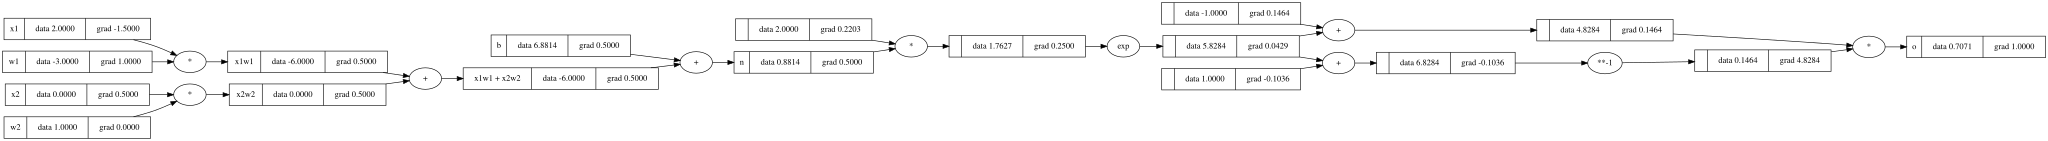

In [21]:
draw_dot(o)

In [22]:
o.backward()

In [23]:
"""o.grad = 1.0
#n.grad = 0.5
# Recall tanh = (e**2x - 1)/(e**2x + 1)
# dy/dx of tanh = (4e**2x)/((e**2x + 1)**2) or 1 -tanh**2 *x = 1 - o**2
n.grad = 0.5
# By implication of the addition operator which distributes it gradients,b.grad, x1w1.grad, x2w2.grad and x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x1w1x2w2.grad = 0.5
b.grad = 0.5

# do/dw1 = do/dx1w1 * dx1w1/dw --> 0.5 * 2.000
w1.grad = 1.0
# do/dx1 = do/dx1w1 * dx1w1/dx1 --> 0.5 * -3.00
x1.grad = -1.50
# do/dx2 = do/dx2w2 * dx2w2/dx2 --> 0.5 * 1.0
x2.grad = 0.5
# do/dw2 = do/dx2w2 * dx2w2/dw2 --> 0.5 * 0.0
w2.grad = 0.0
 
n_grad = (4* math.exp(2*n))/((math.exp(2*n) + 1)**2)
n_grad 
"""

'o.grad = 1.0\n#n.grad = 0.5\n# Recall tanh = (e**2x - 1)/(e**2x + 1)\n# dy/dx of tanh = (4e**2x)/((e**2x + 1)**2) or 1 -tanh**2 *x = 1 - o**2\nn.grad = 0.5\n# By implication of the addition operator which distributes it gradients,b.grad, x1w1.grad, x2w2.grad and x1w1x2w2.grad = 0.5\nx1w1.grad = 0.5\nx2w2.grad = 0.5\nx1w1x2w2.grad = 0.5\nb.grad = 0.5\n\n# do/dw1 = do/dx1w1 * dx1w1/dw --> 0.5 * 2.000\nw1.grad = 1.0\n# do/dx1 = do/dx1w1 * dx1w1/dx1 --> 0.5 * -3.00\nx1.grad = -1.50\n# do/dx2 = do/dx2w2 * dx2w2/dx2 --> 0.5 * 1.0\nx2.grad = 0.5\n# do/dw2 = do/dx2w2 * dx2w2/dw2 --> 0.5 * 0.0\nw2.grad = 0.0\n\nn_grad = (4* math.exp(2*n))/((math.exp(2*n) + 1)**2)\nn_grad \n'

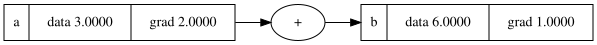

In [24]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

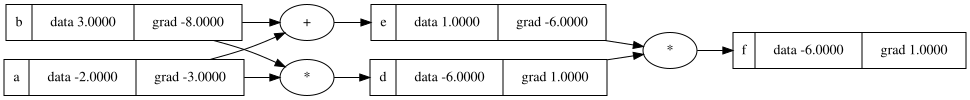

In [25]:
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a * b  ;  d.label = 'd'
e = a + b  ;  e.label = 'e'
f = d * e  ;  f.label = 'f'
f.backward()
draw_dot(f)


### Implementing same Neural Network with PyTorch.

In [26]:
import torch
import random

In [27]:
x1 = torch.Tensor([2.0]).double()      ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()      ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()     ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()      ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double();b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()
print('_______')
print("x2", x2.grad.item())
print("w2", w2.grad.item())
print("x1", x1.grad.item())
print("w1", w1.grad.item())

0.7071066904050358
_______
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [28]:
class Neuron:
     def __init__(self, nin):   # Number of inputs --> nin
          self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
          self.b = Value(random.uniform(-1,1))

     def __call__(self, x):
          # w * x + b 
          act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
          out = act.tanh()
          return out
     def parameters(self): 
          return self.w + [self.b] 

x = [2.0, 3.0]
n = Neuron(2)
n(x) 

class Layer:
     def __init__(self, nin, nout):
          self.neurons = [Neuron(nin) for _ in range(nout)] 
     
     def __call__(self, x):
          outs = [n(x) for n in self.neurons]
          return outs[0] if len(outs) == 1 else outs
     
     def parameters(self):
          return [p for neuron in self.neurons for p in neuron.parameters()]
         
     
class MLP:

     def __init__(self, nin, nouts):
          sz = [nin] + nouts
          self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

     def __call__(self, x):
          for layer in self.layers:
               x = layer(x)
          return x           

     def parameters(self):
          return [p for layer in self.layers for p in layer.parameters()]




In [29]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)




Value(data = -0.6613153161354913)

In [30]:
n.parameters()

[Value(data = -0.5425576157968801),
 Value(data = -0.6202127696758926),
 Value(data = 0.6019176072749055),
 Value(data = -0.47803117619884605),
 Value(data = 0.20655832381335926),
 Value(data = -0.12279873751315229),
 Value(data = 0.7053164990087686),
 Value(data = -0.28401384088031567),
 Value(data = -0.7580484533617278),
 Value(data = -0.7839984516874274),
 Value(data = -0.45701434372353744),
 Value(data = -0.21948507416091712),
 Value(data = -0.9752616987884395),
 Value(data = -0.8426207192078248),
 Value(data = 0.5741129862731058),
 Value(data = -0.4539937500817164),
 Value(data = 0.00595742574323066),
 Value(data = 0.243385286522126),
 Value(data = -0.8580680581610018),
 Value(data = 0.5864848281951538),
 Value(data = -0.6737455672448136),
 Value(data = 0.035523595487145565),
 Value(data = -0.4199698349966843),
 Value(data = 0.28151166579663967),
 Value(data = -0.9761052655668954),
 Value(data = -0.13453013393995783),
 Value(data = 0.9163741791946742),
 Value(data = 0.062387207767

In [31]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets


In [53]:
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
        
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 0.0017196482114313115
1 0.0017129106042389937
2 0.0017062250913621021
3 0.0016995910741398755
4 0.0016930079630173562
5 0.0016864751773734204
6 0.0016799921453526374
7 0.0016735583037008066
8 0.0016671730976043127
9 0.0016608359805330235
10 0.00165454641408659
11 0.0016483038678442841
12 0.001642107819218032
13 0.0016359577533087775
14 0.0016298531627658823
15 0.0016237935476496816
16 0.0016177784152970015
17 0.001611807280189522
18 0.0016058796638251352
19 0.001599995094591885


In [33]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss


Value(data = 0.02240357505202188)

In [34]:
loss.backward()

In [35]:
n.layers[0].neurons[0].w[0].grad

-0.022740406468634195

In [36]:
n.layers[0].neurons[0].w[0].data

-0.04029627388333745

In [37]:
for p in n.parameters():
    p.data += -0.01 *p.grad

In [38]:
n.layers[0].neurons[0].w[0].data

-0.04006886981865111

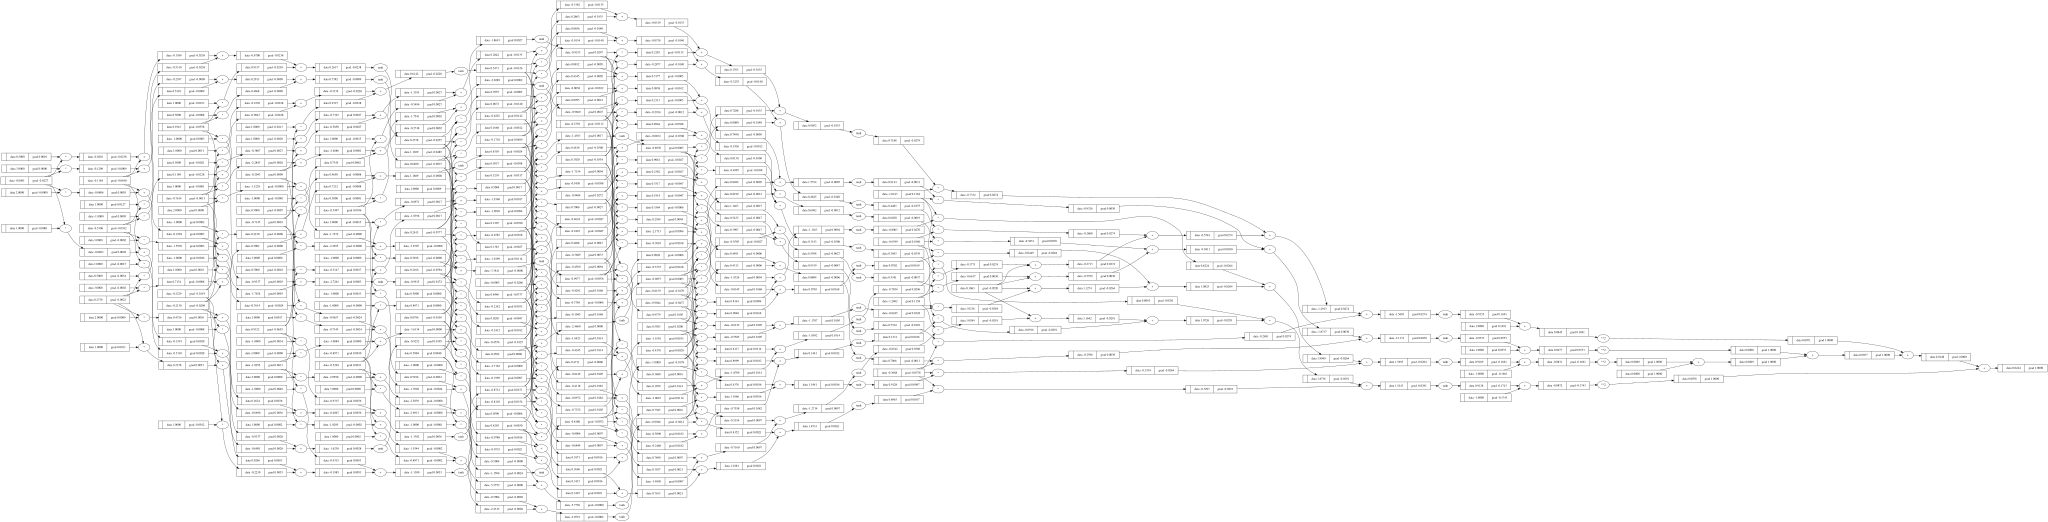

In [39]:
draw_dot(loss)

In [55]:
ypred

[Value(data = 0.9793046979399621),
 Value(data = -0.9899817725999318),
 Value(data = -0.9761890487952869),
 Value(data = 0.9775417433952907)]